In [ ]:
# === [0] Setup + link prediction <-> image (LOCAL, no GPU) ===
# Link JSON<->image by replicating split (SEED=0). Verified alignment by pid + gt_boxes.
import os, json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr
from collections import defaultdict, Counter

HERE = os.getcwd()                                   # run inside seminar/code/
DATA_DIR  = os.path.join(HERE, "data", "data_liver_multi_v3")
JSON_PATH = os.path.join(HERE, "eval", "eval_pred_gemma4_v3_0628_050605.json")  # change if needed
SEED = 0; COORD = 1000
rng_viz = np.random.default_rng(42)                  # separate seed for reproducible examples

def iou(b1, b2):
    if not b1 or not b2: return 0.0
    xa,ya=max(b1[0],b2[0]),max(b1[1],b2[1]); xb,yb=min(b1[2],b2[2]),min(b1[3],b2[3])
    inter=max(0,xb-xa)*max(0,yb-ya)
    a1=max(0,b1[2]-b1[0])*max(0,b1[3]-b1[1]); a2=max(0,b2[2]-b2[0])*max(0,b2[3]-b2[1])
    u=a1+a2-inter; return inter/u if u>0 else 0.0

def gt_overlap_ious(preds, gts):
    """Per-GT max IoU against any prediction. IoU > 0 means coarse overlap-detected."""
    return [max((iou(pred_box, gt_box) for pred_box in preds), default=0.0) for gt_box in gts]

def match_details(preds, gts):
    """Hungarian 1-1. Per-GT IoU keeps unmatched GT = 0, so missing boxes are penalized."""
    n_pred, n_gt = len(preds), len(gts)
    if not preds or not gts:
        return [], n_pred, n_gt, [0.0] * n_gt
    M=np.zeros((n_pred,n_gt))
    for i,pred_box in enumerate(preds):
        for j,gt_box in enumerate(gts): M[i,j]=iou(pred_box,gt_box)
    ri,ci=linear_sum_assignment(1-M)
    matches=[float(M[r,c]) for r,c in zip(ri,ci)]
    gt_ious=[0.0]*n_gt
    for r,c in zip(ri,ci): gt_ious[c]=float(M[r,c])
    return matches, n_pred, n_gt, gt_ious

def _annotate_metrics(r):
    mi, npd, ngt, gt_ious = match_details(r.get("pred_boxes", []), r.get("gt_boxes", []))
    r["matched_ious"] = mi
    r["gt_ious"] = gt_ious
    r["gt_overlap_ious"] = gt_overlap_ious(r.get("pred_boxes", []), r.get("gt_boxes", []))
    r["n_pred"] = npd
    r["n_gt"] = ngt
    r["best_iou"] = max((iou(pp,b) for b in r.get("gt_boxes", []) for pp in r.get("pred_boxes", [])), default=0.0)
    r["match_iou"] = float(np.mean(mi)) if mi else 0.0                  # matched pairs only
    d = max(npd, ngt)
    r["pen_iou"] = float(sum(mi) / d) if d else 0.0                    # penalize missing/extra boxes
    return r

def _area(b): return (b[2]-b[0])*(b[3]-b[1])
def _cnt_str(c): return " | ".join(f"{k}:{c.get(k,0)}" for k in ["nho","vua","lon"])

def load_img(rel): return Image.open(os.path.join(DATA_DIR, rel)).convert("L")

def draw_box(ax, box, color, W, H, lw=1.6):
    x1,y1,x2,y2 = box[0]/COORD*W, box[1]/COORD*H, box[2]/COORD*W, box[3]/COORD*H
    ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, edgecolor=color, linewidth=lw))

def zoom(ax, box, W, H, pad=75):
    cx,cy=(box[0]+box[2])/2*W/COORD,(box[1]+box[3])/2*H/COORD
    ax.set_xlim(cx-pad,cx+pad); ax.set_ylim(cy+pad,cy-pad)   # reversed ylim because origin is upper-left

# --- replicate split exactly like the main notebook split cell ---
rows = [json.loads(l) for l in open(os.path.join(DATA_DIR,"data.jsonl"), encoding="utf-8")]
rng = np.random.default_rng(SEED)
pids = sorted({r["patient_id"] for r in rows}); rng.shuffle(pids)
n=len(pids); n_tr,n_ca=int(n*0.6),int(n*0.2)
tr=set(pids[:n_tr]); ca=set(pids[n_tr:n_tr+n_ca])
test_rows=[r for r in rows if r["patient_id"] not in tr and r["patient_id"] not in ca]

d=json.load(open(JSON_PATH, encoding="utf-8")); preds=d["test"]; cal=d["cal"]
assert len(test_rows)==len(preds), f"len mismatch {len(test_rows)} vs {len(preds)}"
for i,(r,pred) in enumerate(zip(test_rows,preds)):
    assert r["patient_id"]==pred["pid"] and r["gt_boxes"]==pred["gt_boxes"], f"MISALIGNED i={i} (split mismatch?)"
records=[{**{k:r[k] for k in ["image_path","gt_boxes","patient_id"]},
          "pred_boxes":pred["pred_boxes"], "is_pos":pred["is_pos"],
          "logprob":pred["logprob"], "spatial":pred["spatial"], "selfconf":pred["selfconf"]}
         for r,pred in zip(test_rows,preds)]
for r in records: _annotate_metrics(r)

# lesion size tertiles over all positive test lesions
all_areas=[_area(b) for r in records if r["is_pos"] for b in r["gt_boxes"]]
Q1,Q2=np.percentile(all_areas,[33,67])
def size_cat(area): return "nho" if area<Q1 else ("vua" if area<Q2 else "lon")
print(f"Link OK: {len(records)} slices ({sum(r['is_pos'] for r in records)} positive) | "
      f"{len(all_areas)} lesions | size tertiles: q1={Q1/1e4:.2f}% q2={Q2/1e4:.2f}% image")

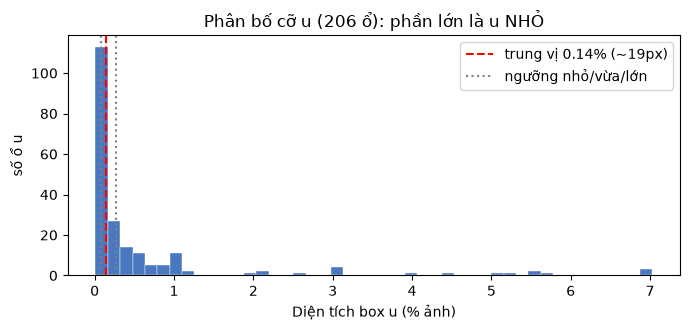

In [11]:
# === [1] Phân bố cỡ u — DATA NGẬP U NHỎ (gốc của recall thấp) ===
ap=np.array(all_areas)/1e4
plt.figure(figsize=(7,3.4))
plt.hist(ap,bins=45,color="#4a78c0",edgecolor="white",linewidth=.3)
plt.axvline(np.median(ap),color="red",ls="--",lw=1.5,label=f"trung vị {np.median(ap):.2f}% (~{np.sqrt(np.median(all_areas))*512/1000:.0f}px)")
plt.axvline(Q1/1e4,color="gray",ls=":"); plt.axvline(Q2/1e4,color="gray",ls=":",label="ngưỡng nhỏ/vừa/lớn")
plt.xlabel("Diện tích box u (% ảnh)"); plt.ylabel("số ổ u")
plt.title(f"Phân bố cỡ u ({len(all_areas)} ổ): phần lớn là u NHỎ"); plt.legend(); plt.tight_layout(); plt.show()

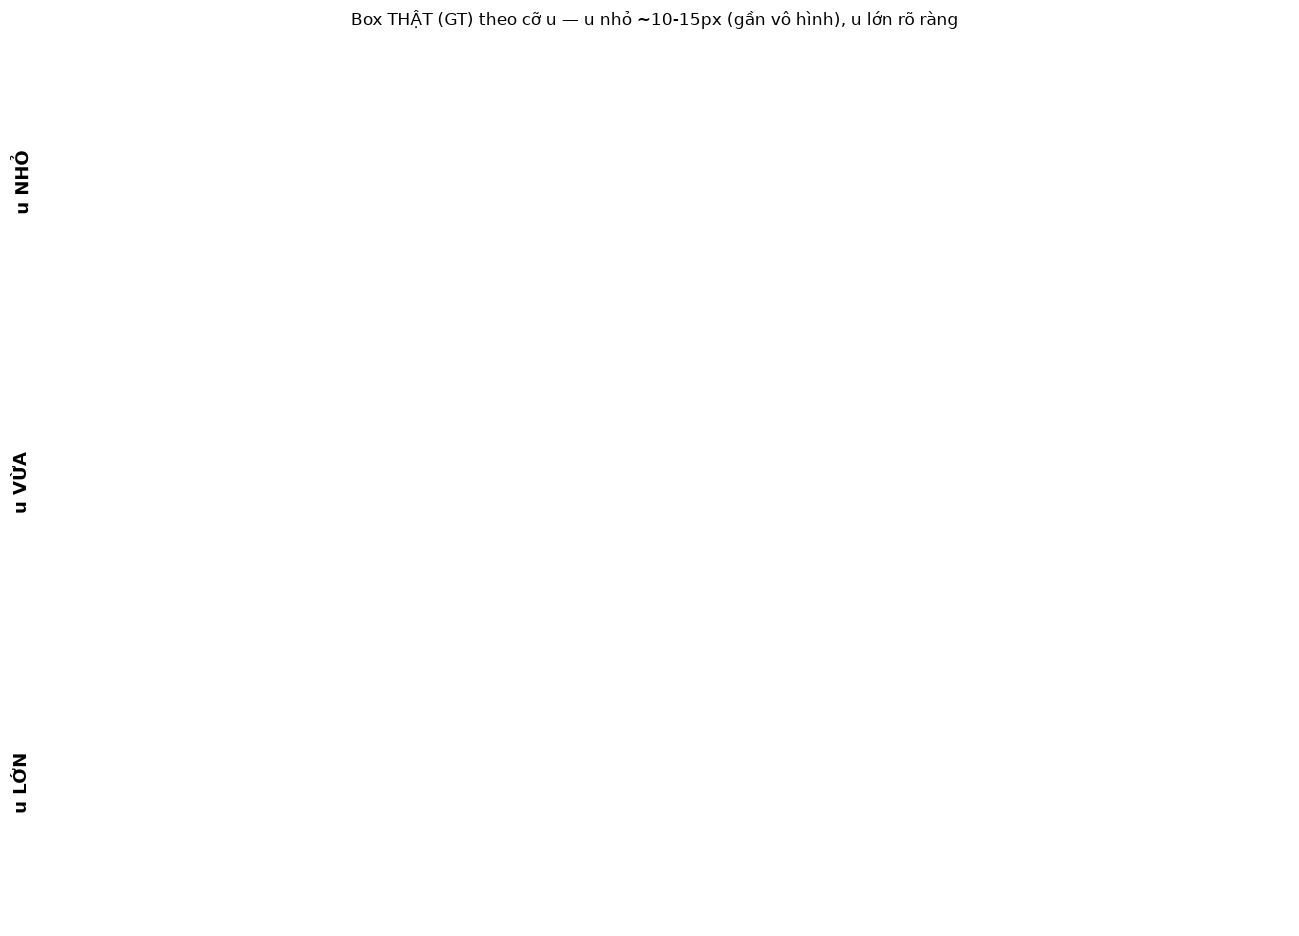

In [20]:
# === [2] GT box theo 3 CỠ u (xanh=GT) — hàng NHỎ đã zoom ===
single=[r for r in records if r["is_pos"] and len(r["gt_boxes"])==1]
bysz=defaultdict(list)
for r in single:
    b=r["gt_boxes"][0]; bysz[size_cat((b[2]-b[0])*(b[3]-b[1]))].append(r)
fig,axes=plt.subplots(3,4,figsize=(13,9.5))
for ri,sz in enumerate(["nhỏ","vừa","lớn"]):
    pool=bysz[sz][:]; rng_viz.shuffle(pool); pick=pool[:4]
    for ci in range(4):
        ax=axes[ri,ci]; ax.axis("off")
        if ci>=len(pick): continue
        r=pick[ci]; img=load_img(r["image_path"]); W,H=img.size; box=r["gt_boxes"][0]
        ax.imshow(img,cmap="gray"); draw_box(ax,box,"lime",W,H)
        if sz=="nhỏ": zoom(ax,box,W,H)
        a=(box[2]-box[0])*(box[3]-box[1]); ax.set_title(f"{a/1e4:.2f}% ảnh",fontsize=9)
    axes[ri,0].text(-0.12,0.5,f"u {sz.upper()}",transform=axes[ri,0].transAxes,
                    fontsize=13,fontweight="bold",rotation=90,va="center")
fig.suptitle("Box THẬT (GT) theo cỡ u — u nhỏ ~10-15px (gần vô hình), u lớn rõ ràng",fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# === [3] Model PREDICT (red) vs GT (green) by size ===
# Shows both coarse overlap-detect and stricter IoU@0.25 localization.
lesions=[]
for r in records:
    if not r["is_pos"]: continue
    for bi,b in enumerate(r["gt_boxes"]):
        giou = r["gt_ious"][bi] if bi < len(r["gt_ious"]) else 0.0
        oiou = r["gt_overlap_ious"][bi] if bi < len(r["gt_overlap_ious"]) else 0.0
        lesions.append({"r":r,"box":b,"iou":giou,"overlap_iou":oiou,"cat":size_cat(_area(b))})
fig,axes=plt.subplots(3,4,figsize=(13,9.5))
for ri,sz in enumerate(["nho","vua","lon"]):
    grp=[L for L in lesions if L["cat"]==sz]
    rec=np.mean([L["iou"]>=0.25 for L in grp]) if grp else 0
    det=np.mean([L["overlap_iou"]>0 for L in grp]) if grp else 0
    hit=sorted([L for L in grp if L["iou"]>=0.25],key=lambda x:-x["iou"])[:2]
    weak=[L for L in grp if L["overlap_iou"]>0 and L["iou"]<0.25]; rng_viz.shuffle(weak)
    miss=[L for L in grp if L["overlap_iou"]<=0]; rng_viz.shuffle(miss)
    pick=(hit+weak[:1]+miss[:1])[:4]
    for ci in range(4):
        ax=axes[ri,ci]; ax.axis("off")
        if ci>=len(pick): continue
        L=pick[ci]; r=L["r"]; img=load_img(r["image_path"]); W,H=img.size
        ax.imshow(img,cmap="gray"); draw_box(ax,L["box"],"lime",W,H)
        for pred_box in r["pred_boxes"]: draw_box(ax,pred_box,"red",W,H,lw=1.2)
        if sz=="nho": zoom(ax,L["box"],W,H,80)
        ok=L["iou"]>=0.25
        title = f"GT-IoU {L['iou']:.2f}" if ok else (f"OVERLAP {L['overlap_iou']:.2f}" if L["overlap_iou"]>0 else "NO OVERLAP")
        ax.set_title(title,fontsize=10,color=("green" if ok else "red"),fontweight="bold")
    axes[ri,0].text(-0.12,0.5,f"u {sz.upper()}\\noverlap {det:.0%}\\nIoU.25 {rec:.0%}",transform=axes[ri,0].transAxes,
                    fontsize=12,fontweight="bold",rotation=90,va="center")
fig.suptitle("Predict (red) vs GT (green): overlap counts as coarse detect; IoU@0.25 counts localization",fontsize=12)
plt.tight_layout(); plt.show()

Positive slices with NO predicted box: 49/120
  By SLICE, using largest lesion size: nho:19 | vua:19 | lon:11
  By GT lesion inside missed slices:    nho:23 | vua:19 | lon:11


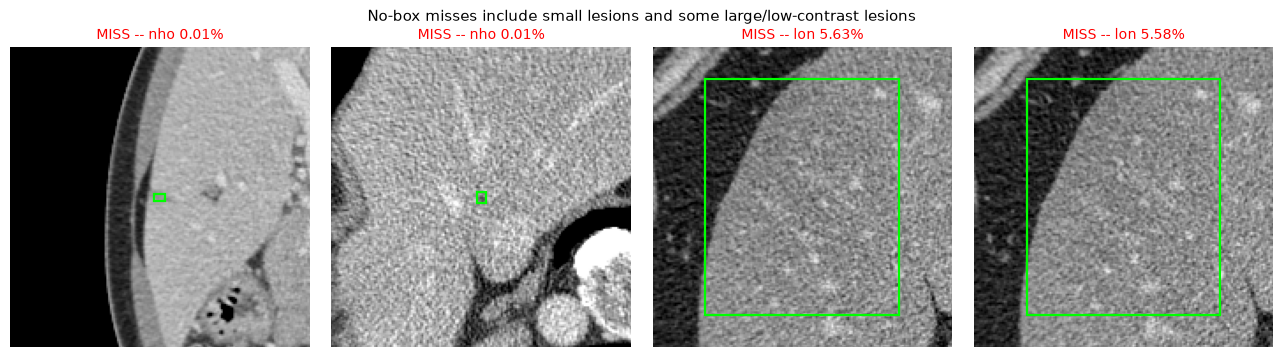

In [14]:
# === [4] FAILURE CASES -- positive slices where model draws NO box ===
# Print size distribution so the story is not one-sided.
pos=[r for r in records if r["is_pos"]]
no_box=[r for r in pos if len(r["pred_boxes"])==0]
miss_lesions=[]
for r in no_box:
    for b in r["gt_boxes"]:
        a=_area(b); miss_lesions.append({"r":r,"box":b,"area":a,"cat":size_cat(a)})
les_cnt=Counter(x["cat"] for x in miss_lesions)
slice_cnt=Counter(size_cat(max(_area(b) for b in r["gt_boxes"])) for r in no_box)
print(f"Positive slices with NO predicted box: {len(no_box)}/{len(pos)}")
print(f"  By SLICE, using largest lesion size: {_cnt_str(slice_cnt)}")
print(f"  By GT lesion inside missed slices:    {_cnt_str(les_cnt)}")
small=sorted([x for x in miss_lesions if x["cat"]=="nho"], key=lambda x:x["area"])[:2]
large=sorted([x for x in miss_lesions if x["cat"]=="lon"], key=lambda x:-x["area"])[:2]
pick=(small+large)[:4]
if len(pick)<4:
    used={(id(x["r"]), tuple(x["box"])) for x in pick}
    fill=[x for x in sorted(miss_lesions, key=lambda x:-x["area"]) if (id(x["r"]), tuple(x["box"])) not in used]
    pick += fill[:4-len(pick)]
fig,axes=plt.subplots(1,4,figsize=(13,3.6))
for ax,L in zip(axes,pick):
    r=L["r"]; img=load_img(r["image_path"]); W,H=img.size; box=L["box"]
    ax.imshow(img,cmap="gray"); draw_box(ax,box,"lime",W,H); zoom(ax,box,W,H,85); ax.axis("off")
    ax.set_title(f"MISS -- {L['cat']} {L['area']/1e4:.2f}%",fontsize=10,color="red")
for ax in axes[len(pick):]: ax.axis("off")
fig.suptitle("No-box misses include small lesions and some large/low-contrast lesions",fontsize=11)
plt.tight_layout(); plt.show()

## Vi sao model bo sot? -- khong chi do u nho

Cell audit ben duoi tach tung GT lesion bi thieu theo 3 truc: kich thuoc, do tuong phan cuc bo, va tinh huong multi-box/undercount.

- Neu lesion nho hoac contrast thap: day nghieng ve **anh qua kho nhin / cat lat-windowing lam tin hieu yeu**.
- Neu lesion vua/lon, contrast khong thap ma van miss: day nghieng ve **model bo sot / decision detect chua tot / train chua hoc du**.

Do tuong phan o day chi la proxy tu PNG windowed CT quanh box, khong phai tumor mask that, nen dung de soi xu huong chu khong ket luan lam sang manh.


5 missed patients / 25 positive patients
  Mean largest-lesion area: missed 1.28% vs detected 1.32% image
  Missed patients by largest-lesion size: nho:0 | vua:3 | lon:2
  Detected patients by largest-lesion size: nho:1 | vua:6 | lon:13
  -> Missing is not only size; some large lesions have low contrast / are isointense.


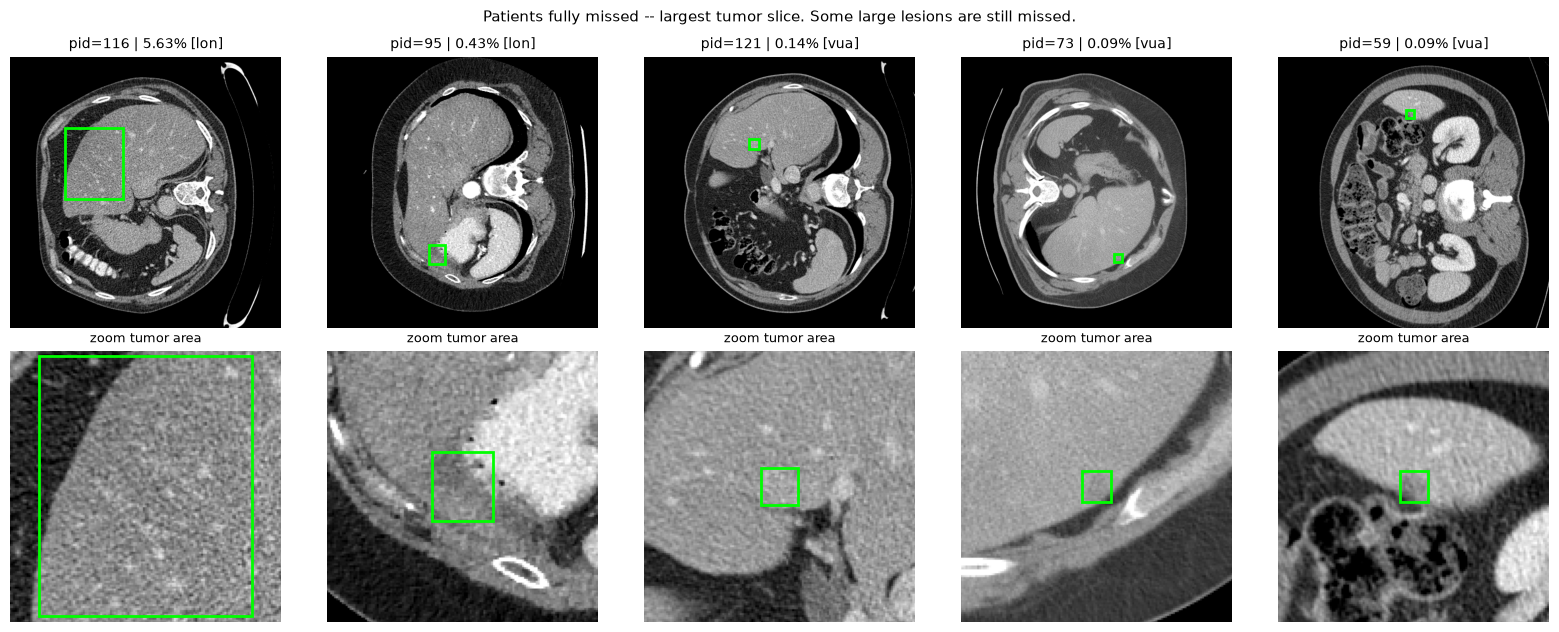

In [15]:
# === [Missed patients] Patients where model draws 0 boxes on ALL positive slices ===
# Missing is not only about size: some large lesions are low-contrast / isointense.
bp = defaultdict(lambda: {"det": False, "sl": []})
for r in records:
    if r["is_pos"]:
        bp[r["patient_id"]]["sl"].append(r)
        if r["pred_boxes"]: bp[r["patient_id"]]["det"] = True
missed = [pid for pid, v in bp.items() if not v["det"]]
det    = [pid for pid, v in bp.items() if v["det"]]
def _maxarea(pid): return max(_area(b) for r in bp[pid]["sl"] for b in r["gt_boxes"])
miss_cat = Counter(size_cat(_maxarea(p)) for p in missed)
det_cat  = Counter(size_cat(_maxarea(p)) for p in det)
print(f"{len(missed)} missed patients / {len(bp)} positive patients")
if missed and det:
    print(f"  Mean largest-lesion area: missed {np.mean([_maxarea(p) for p in missed])/1e4:.2f}% "
          f"vs detected {np.mean([_maxarea(p) for p in det])/1e4:.2f}% image")
print(f"  Missed patients by largest-lesion size: {_cnt_str(miss_cat)}")
print(f"  Detected patients by largest-lesion size: {_cnt_str(det_cat)}")
print("  -> Missing is not only size; some large lesions have low contrast / are isointense.")

sel = sorted(missed, key=lambda p: -_maxarea(p))                  # largest first
fig, axs = plt.subplots(2, max(len(sel), 1), figsize=(3.2*max(len(sel), 1), 6.4))
axs = np.atleast_2d(axs)
for j, pid in enumerate(sel):
    r = max(bp[pid]["sl"], key=lambda r: max(_area(b) for b in r["gt_boxes"]))
    img = load_img(r["image_path"]); W, H = img.size
    b = max(r["gt_boxes"], key=_area)
    axs[0][j].imshow(img, cmap="gray"); draw_box(axs[0][j], b, "lime", W, H, 2)
    axs[0][j].set_title(f"pid={pid} | {_area(b)/1e4:.2f}% [{size_cat(_area(b))}]", fontsize=10); axs[0][j].axis("off")
    axs[1][j].imshow(img, cmap="gray"); draw_box(axs[1][j], b, "lime", W, H, 2); zoom(axs[1][j], b, W, H, pad=70)
    axs[1][j].set_title("zoom tumor area", fontsize=9); axs[1][j].axis("off")
plt.suptitle("Patients fully missed -- largest tumor slice. Some large lesions are still missed.", fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# === [4b] Missing-lesion audit: overlap-detect / localization / contrast ===
# Coarse detect: any predicted box overlaps the GT lesion (max IoU > 0).
# Good localization is still reported separately at IoU >= LOC_THR.
LOC_THR = 0.25

def _box_px(box, W, H, pad=0):
    x1 = int(np.floor(box[0] / COORD * W)) - pad
    y1 = int(np.floor(box[1] / COORD * H)) - pad
    x2 = int(np.ceil (box[2] / COORD * W)) + pad
    y2 = int(np.ceil (box[3] / COORD * H)) + pad
    x1=max(0,min(W-1,x1)); y1=max(0,min(H-1,y1)); x2=max(x1+1,min(W,x2)); y2=max(y1+1,min(H,y2))
    return x1,y1,x2,y2

def _lesion_features(rec, box):
    img=np.asarray(load_img(rec["image_path"]), dtype=np.float32)
    H,W=img.shape
    x1,y1,x2,y2=_box_px(box,W,H,0)
    crop=img[y1:y2,x1:x2]
    bw,bh=x2-x1,y2-y1
    pad=max(8, int(max(bw,bh)*1.5))
    rx1,ry1,rx2,ry2=_box_px(box,W,H,pad)
    local=img[ry1:ry2,rx1:rx2]
    mask=np.ones(local.shape, dtype=bool)
    ix1,iy1=x1-rx1,y1-ry1; ix2,iy2=x2-rx1,y2-ry1
    mask[iy1:iy2, ix1:ix2]=False
    ring=local[mask]
    if ring.size < 16: ring=local.reshape(-1)
    # Rough proxy only: PNG is windowed CT; box crop is not a true tumor mask.
    diff=float(crop.mean()-ring.mean()) if crop.size and ring.size else 0.0
    abs_diff=abs(diff)
    norm_diff=abs_diff/(float(ring.std())+1e-6)
    gy,gx=np.gradient(crop) if crop.size > 1 else (np.array([0.0]),np.array([0.0]))
    edge=float(np.mean(np.sqrt(gx*gx+gy*gy))) if crop.size > 1 else 0.0
    return dict(area=_area(box), area_pct=_area(box)/1e4, short_px=min(bw,bh), long_px=max(bw,bh),
                contrast=abs_diff, contrast_z=norm_diff, contrast_signed=diff, edge=edge)

lesions=[]
for rec in records:
    if not rec["is_pos"]: continue
    for bi,box in enumerate(rec["gt_boxes"]):
        gt_iou = rec["gt_ious"][bi] if bi < len(rec["gt_ious"]) else 0.0
        overlap_iou = rec["gt_overlap_ious"][bi] if bi < len(rec["gt_overlap_ious"]) else 0.0
        feat = _lesion_features(rec, box)
        lesions.append({**feat, "r":rec, "box":box, "gt_iou":gt_iou, "overlap_iou":overlap_iou,
                        "overlap_detected": overlap_iou > 0,
                        "localized": gt_iou >= LOC_THR,
                        "miss": overlap_iou <= 0,
                        "cat": size_cat(feat["area"]),
                        "no_box_slice": rec["n_pred"] == 0,
                        "multi_gt": rec["n_gt"] > 1,
                        "under_count": rec["n_pred"] < rec["n_gt"]})
miss=[x for x in lesions if x["miss"]]
overlap_hit=[x for x in lesions if x["overlap_detected"]]
poor_loc=[x for x in lesions if x["overlap_detected"] and not x["localized"]]
good_loc=[x for x in lesions if x["localized"]]
contrast_cut=np.nanpercentile([x["contrast_z"] for x in lesions], 33) if lesions else 0.0
hit_med_contrast=np.nanmedian([x["contrast_z"] for x in overlap_hit]) if overlap_hit else float("nan")
for x in lesions:
    x["low_contrast"] = x["contrast_z"] <= contrast_cut
    x["hard_image"] = (x["cat"] == "nho") or x["low_contrast"]

def _med(xs, key):
    return float(np.nanmedian([x[key] for x in xs])) if xs else float("nan")
def _mean(xs, key):
    return float(np.nanmean([x[key] for x in xs])) if xs else float("nan")
def _rate(xs, pred):
    return sum(pred(x) for x in xs) / len(xs) if xs else 0.0

def _print_group(name, xs):
    print(f"{name:18} n={len(xs):3} | area med { _med(xs,'area_pct'):.3f}% | short_px med {_med(xs,'short_px'):.1f} | "
          f"contrast_z med {_med(xs,'contrast_z'):.2f} | low-contrast {_rate(xs,lambda z:z['low_contrast']):.0%} | multi-GT {_rate(xs,lambda z:z['multi_gt']):.0%}")

print("DETECT definition: max IoU with any predicted box > 0 (coarse overlap)")
print(f"GOOD localization definition: Hungarian 1-1 GT IoU >= {LOC_THR}")
print(f"Total lesions: {len(lesions)} | overlap-detected {len(overlap_hit)} ({_rate(lesions,lambda z:z['overlap_detected']):.0%}) | "
      f"no-overlap miss {len(miss)} ({_rate(lesions,lambda z:z['miss']):.0%}) | localized-good {len(good_loc)} ({_rate(lesions,lambda z:z['localized']):.0%})")
print(f"Low-contrast cutoff: bottom third contrast_z <= {contrast_cut:.2f}; hit median contrast_z = {hit_med_contrast:.2f}")
print()
_print_group("OVERLAP-DETECTED", overlap_hit)
_print_group("NO-OVERLAP MISS", miss)
_print_group("OVERLAP, IoU<.25", poor_loc)
print()
print("No-overlap missed lesions by size:", _cnt_str(Counter(x["cat"] for x in miss)))
print("Overlap but low-IoU lesions by size:", _cnt_str(Counter(x["cat"] for x in poor_loc)))
print("No-overlap missed lesions by mode:",
      f"no-box-slice={sum(x['no_box_slice'] for x in miss)} | has-box-but-no-overlap={sum(not x['no_box_slice'] for x in miss)}")
print("No-overlap misses likely image-hard (small OR low contrast):",
      f"{sum(x['hard_image'] for x in miss)}/{len(miss)} ({_rate(miss,lambda z:z['hard_image']):.0%})")
easy_miss=[x for x in miss if not x["hard_image"]]
print("Easy-looking no-overlap misses (not small and not low contrast):",
      f"{len(easy_miss)}/{len(miss)} -> more likely model/decision/training issue")

fig,ax=plt.subplots(1,1,figsize=(6.8,4.5))
for name,xs,color,marker in [("localized-good",good_loc,"#2ca02c","o"),("overlap low-IoU",poor_loc,"#ff7f0e","^"),("no-overlap miss",miss,"#d62728","x")]:
    ax.scatter([x["area_pct"] for x in xs], [x["contrast_z"] for x in xs], s=28, alpha=.75, c=color, marker=marker, label=name)
ax.axhline(contrast_cut,color="gray",ls=":",lw=1,label="low contrast cutoff")
ax.axvline(Q1/1e4,color="gray",ls="--",lw=1); ax.axvline(Q2/1e4,color="gray",ls="--",lw=1)
ax.set_xscale("log"); ax.set_xlabel("GT box area (% image, log scale)"); ax.set_ylabel("local contrast z-score (rough)")
ax.set_title("Lesions by detect tier: overlap vs localization quality")
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

# Show representative cases: true misses, overlap-but-poor boxes, then easy-looking true misses.
hard_pick=sorted([x for x in miss if x["hard_image"]], key=lambda x:(x["contrast_z"], x["area"]))[:4]
poor_pick=sorted(poor_loc, key=lambda x:(-x["area"], -x["overlap_iou"]))[:4]
easy_pick=sorted(easy_miss, key=lambda x:(-x["area"], -x["contrast_z"]))[:4]
picks=[hard_pick, poor_pick, easy_pick]
labels=["NO-OVERLAP miss: small/low contrast", "OVERLAP but IoU<.25: detected, poor box", "NO-OVERLAP miss: easy-looking"]
fig,axes=plt.subplots(3,4,figsize=(13,9.4))
for row,pick in enumerate(picks):
    for ci in range(4):
        ax=axes[row,ci]; ax.axis("off")
        if ci>=len(pick): continue
        x=pick[ci]; rec=x["r"]; img=load_img(rec["image_path"]); W,H=img.size
        ax.imshow(img,cmap="gray")
        draw_box(ax,x["box"],"lime",W,H,2)
        for pred_box in rec["pred_boxes"]: draw_box(ax,pred_box,"red",W,H,1.2)
        zoom(ax,x["box"],W,H,85)
        ax.set_title(f"{x['cat']} area {x['area_pct']:.2f}% cZ {x['contrast_z']:.2f} ov {x['overlap_iou']:.2f}",fontsize=9,color=("#ff7f0e" if x['overlap_detected'] and not x['localized'] else "red"))
    axes[row,0].text(-0.13,0.5,labels[row],transform=axes[row,0].transAxes,fontsize=10,
                     fontweight="bold",rotation=90,va="center")
plt.suptitle("Green=GT, red=prediction. Any overlap counts as coarse detect; low IoU means poor localization.",fontsize=11)
plt.tight_layout(); plt.show()

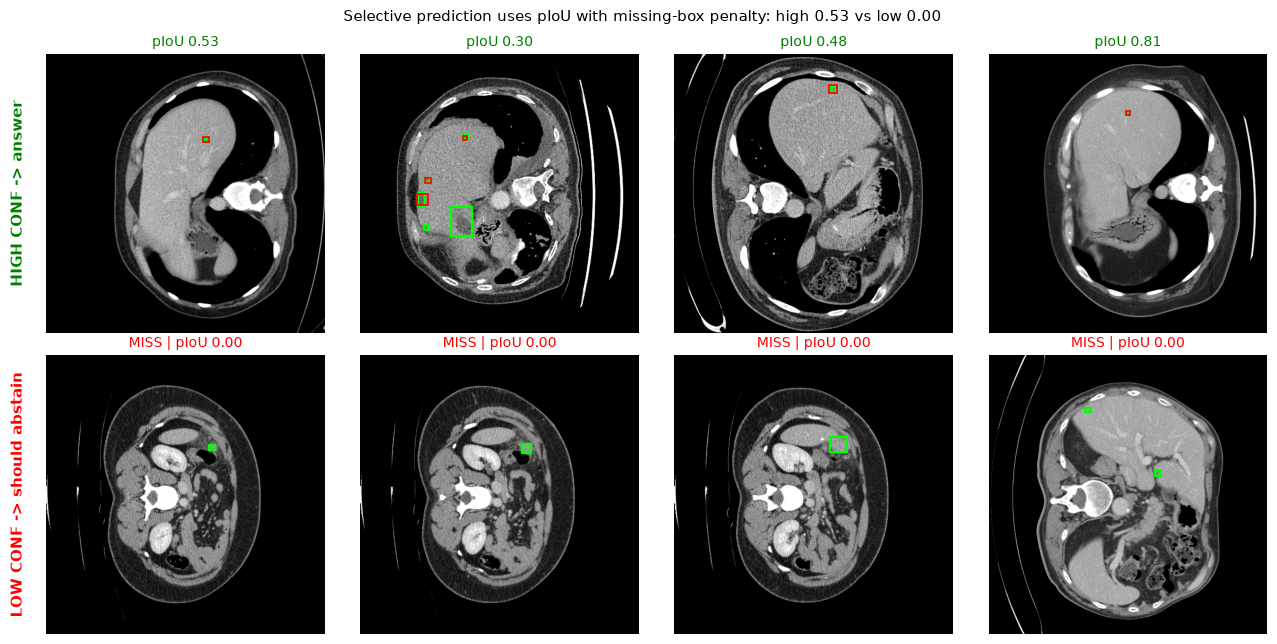

In [17]:
# === [5] SELECTIVE PREDICTION (Direction-1) ===
# Do NOT filter out no-box positives: if model is confident but draws nothing, pIoU must be 0.
pos=[r for r in records if r["is_pos"]]
hi=sorted(pos,key=lambda r:-r["logprob"])[:4]      # high confidence
lo=sorted(pos,key=lambda r: r["logprob"])[:4]      # low confidence
fig,axes=plt.subplots(2,4,figsize=(13,6.6))
for row,(name,grp,col) in enumerate([("HIGH CONF -> answer",hi,"green"),("LOW CONF -> should abstain",lo,"red")]):
    for ci,r in enumerate(grp):
        ax=axes[row,ci]; img=load_img(r["image_path"]); W,H=img.size
        ax.imshow(img,cmap="gray")
        for b in r["gt_boxes"]: draw_box(ax,b,"lime",W,H)
        for pred_box in r["pred_boxes"]: draw_box(ax,pred_box,"red",W,H,lw=1.2)
        title = f"pIoU {r['pen_iou']:.2f}" if r["pred_boxes"] else "MISS | pIoU 0.00"
        ax.set_title(title,fontsize=10,color=("green" if r["pen_iou"]>=0.25 else "red")); ax.axis("off")
    axes[row,0].text(-0.13,0.5,name,transform=axes[row,0].transAxes,fontsize=11,
                     fontweight="bold",rotation=90,va="center",color=col)
hm=np.mean([r["pen_iou"] for r in hi]); lm=np.mean([r["pen_iou"] for r in lo])
fig.suptitle(f"Selective prediction uses pIoU with missing-box penalty: high {hm:.2f} vs low {lm:.2f}",fontsize=11)
plt.tight_layout(); plt.show()

signal      Spearman(cal)
logprob            +0.863
spatial            -0.154
selfconf           +0.729


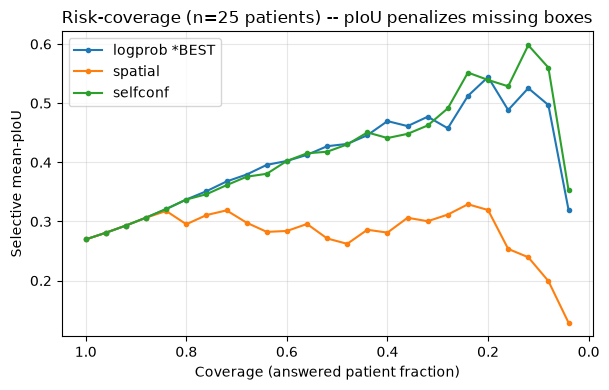


CAVEAT: n=25 patients is small -> proof-of-concept only, not a strong conclusion.


In [18]:
# === [6] Risk-coverage + signal table (cal chooses / test reports) ===
# Quality target = pen_iou: sum matched IoU / max(n_pred,n_gt), so no-box and under-count are penalized.
SIG=["logprob","spatial","selfconf"]
def per_pat(rs):
    bp=defaultdict(list)
    for r in rs:
        if r["is_pos"]: bp[r["patient_id"]].append(r)
    pids=list(bp)
    pi=np.array([np.mean([x["pen_iou"] for x in bp[pid]]) for pid in pids])
    ps={}
    for k in SIG:
        vals=[]
        for pid in pids:
            xs=[x[k] for x in bp[pid] if x.get(k) is not None and np.isfinite(x.get(k))]
            vals.append(float(np.mean(xs)) if xs else np.nan)
        ps[k]=np.array(vals, dtype=float)
    return pi,ps
# cal: attach the same metrics as test
for c in cal:
    c["patient_id"]=c["pid"]
    _annotate_metrics(c)
Ti,Ts=per_pat(records); Ci,Cs=per_pat(cal)
print(f"{'signal':10}{'Spearman(cal)':>15}"); chosen={}; valid=[]
for k in SIG:
    mask=np.isfinite(Cs[k]) & np.isfinite(Ci)
    rho=spearmanr(Cs[k][mask],Ci[mask]).correlation if mask.sum()>1 and np.std(Cs[k][mask])>1e-9 else float('nan')
    chosen[k]=-1.0 if (not np.isnan(rho) and rho<0) else 1.0
    if not np.isnan(rho): valid.append((k,abs(rho)))
    print(f"{k:10}{rho:>+15.3f}")
BEST=max(valid,key=lambda x:x[1])[0] if valid else "logprob"
n=len(Ti); plt.figure(figsize=(6.2,4))
for k in SIG:
    s=chosen[k]*Ts[k]
    mask=np.isfinite(s)
    if mask.sum()==0: continue
    o=np.argsort(-s[mask]); ti=Ti[mask]
    plt.plot([(i+1)/len(ti) for i in range(len(ti))],
        [ti[o[:i+1]].mean() for i in range(len(ti))],marker="o",ms=3,label=k+(" *BEST" if k==BEST else ""))
plt.gca().invert_xaxis(); plt.xlabel("Coverage (answered patient fraction)"); plt.ylabel("Selective mean-pIoU")
plt.title(f"Risk-coverage (n={n} patients) -- pIoU penalizes missing boxes"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print()
print(f"CAVEAT: n={n} patients is small -> proof-of-concept only, not a strong conclusion.")

## Nhận biết có/không u — TÁCH khỏi định vị

Tách 2 trục: **phát hiện** (model nói có u / không = vẽ box hay không) vs **định vị** (box khít cỡ nào, IoU). Model **nhận biết tốt** nhưng **định vị yếu hơn** — bảng dưới đo riêng phần "vẽ box hay không" so với nhãn, độc lập IoU.

**⚠️ Lưu ý:** chỉ ~25 bệnh nhân dương và **chỉ 2 bệnh nhân hoàn toàn không-u** → Spec/Prec 100% **rất yếu về thống kê** (n=2). "Specificity" ở đây = phân biệt lát-có-u vs lát-không-u **trong cùng bệnh nhân CÓ u**, **KHÔNG phải** specificity lâm sàng (phân biệt người bệnh vs người khỏe).


In [ ]:
# === [Nhận biết] Phân loại có/không u (VẼ BOX hay KHÔNG) — TÁCH khỏi định vị (IoU) ===
def _detect_report(rows, level):
    if level == "patient":
        bpx = defaultdict(lambda: [0, 0])
        for r in rows:
            bpx[r["patient_id"]][0] |= int(bool(r["gt_boxes"]))
            bpx[r["patient_id"]][1] |= int(len(r["pred_boxes"]) > 0)
        items = list(bpx.values())
    else:
        items = [[int(bool(r["gt_boxes"])), int(len(r["pred_boxes"]) > 0)] for r in rows]
    TP = sum(g and p for g, p in items); FP = sum((not g) and p for g, p in items)
    TN = sum((not g) and not p for g, p in items); FN = sum(g and not p for g, p in items); n = len(items)
    sens = TP/(TP+FN) if TP+FN else 0; spec = TN/(TN+FP) if TN+FP else 0
    prec = TP/(TP+FP) if TP+FP else 0; f1 = 2*prec*sens/(prec+sens) if prec+sens else 0
    print(f"  [{level:7}] n={n} TP={TP} FP={FP} TN={TN} FN={FN} | "
          f"Sens(bắt u) {sens:.0%} | Spec {spec:.0%} | Prec {prec:.0%} | F1 {f1:.2f}")

print("== NHẬN BIẾT có/không u (vẽ box hay KHÔNG, độc lập IoU) ==")
_detect_report(records, "slice")
_detect_report(records, "patient")
print("  CAVEAT: chỉ 2 bệnh nhân hoàn toàn không-u -> Spec/Prec 100% dựa n=2 (rất yếu);")
print("          'Spec' = phân biệt lát trong cùng người CÓ u, KHÔNG phải specificity lâm sàng.")


In [ ]:
# === [7] Summary table ===
pos=[r for r in records if r["is_pos"]]; neg=[r for r in records if not r["is_pos"]]
print("== LOCALIZATION ==")
ng=sum(r["n_gt"] for r in pos); npd=sum(r["n_pred"] for r in pos)
overlap_tp=sum(sum(v>0 for v in r.get("gt_overlap_ious", [])) for r in pos)
print(f"  overlap-detect(any IoU>0): recall {overlap_tp/ng:.0%} | TP {overlap_tp}/{ng} GT")
for th in [0.1,0.25,0.5,0.75]:
    tp=sum(sum(v>th for v in r["matched_ious"]) for r in pos)
    print(f"  @IoU>{th}: recall {tp/ng:.0%} | precision {(tp/npd if npd else 0):.0%} | TP {tp}/{ng} GT, {npd} pred")
no_box=sum(r["n_pred"]==0 for r in pos)
undercount_nonzero=sum(0<r["n_pred"]<r["n_gt"] for r in pos)
undercount_all=sum(r["n_pred"]<r["n_gt"] for r in pos)
miss_by_count=sum(max(0,r["n_gt"]-r["n_pred"]) for r in pos)
multi_under=sum(r["n_gt"]>1 and r["n_pred"]<r["n_gt"] for r in pos)
print(f"  Full-slice miss (0 box): {no_box}/{len(pos)} positive slices")
print(f"  Under-counted slices incl. 0-box: {undercount_all}/{len(pos)} | multi-box under-counted: {multi_under}")
print(f"  Has boxes but still under-counts: {undercount_nonzero} slices | count-missing = {miss_by_count} GT boxes")

bp=defaultdict(list)
bp_match=defaultdict(list)
for r in pos:
    bp[r["patient_id"]].append(r["pen_iou"])
    bp_match[r["patient_id"]].append(r["match_iou"])
pat=np.array([np.mean(v) for v in bp.values()])
pat_match=np.array([np.mean(bp_match[k]) for k in bp])
rngb=np.random.default_rng(0); idx=np.arange(len(pat))
ci=np.percentile([pat[rngb.choice(idx,len(idx),replace=True)].mean() for _ in range(2000)],[2.5,97.5])
print(f"  per-patient pIoU(missing/extra-box penalty) {pat.mean():.3f} | CI95 [{ci[0]:.3f}, {ci[1]:.3f}] | n={len(pat)} patients")
print(f"  reference only: matched-pair IoU (optimistic) {pat_match.mean():.3f}")

fp=sum(len(r['pred_boxes'])>0 for r in neg)
nbp=defaultdict(list)
for r in neg: nbp[r["patient_id"]].append(len(r["pred_boxes"])>0)
fp_pat=sum(any(v) for v in nbp.values())
print(f"== NEGATIVE SLICES == {len(neg)} slices | FP {fp} ({fp/len(neg):.1%}) | "
      f"per-patient {fp_pat}/{len(nbp)} ({fp_pat/len(nbp):.1%})")
print("   Note: these are tumor-free slices from patients with tumors, not clinical specificity on healthy patients.")

print()
print("== RECALL BY TUMOR SIZE ==")
les=[(_area(b),
      r["gt_ious"][bi] if bi < len(r["gt_ious"]) else 0.0,
      r["gt_overlap_ious"][bi] if bi < len(r["gt_overlap_ious"]) else 0.0)
     for r in pos for bi,b in enumerate(r["gt_boxes"])]
A=np.array([a for a,_,_ in les]); B=np.array([b for _,b,_ in les]); C=np.array([c for _,_,c in les])
for nm,lo,hi in [("NHO",A.min()-1,Q1),("VUA",Q1,Q2),("LON",Q2,A.max()+1)]:
    m=(A>=lo)&(A<hi)
    print(f"  {nm:5} n={int(m.sum()):3} overlap-detect={(C[m]>0).mean():.0%} "
          f"recall@.25={(B[m]>0.25).mean():.0%} recall@.5={(B[m]>0.5).mean():.0%}  GT-IoU={B[m].mean():.3f}")